## 1. Načítanie a prvý prehľad dát

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#nastavenie vzhladu grafov.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#zobrazenie grafov priamo v notebooku
%matplotlib inline

#nacitanie datasetu
df = pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
#pocet riadkov a stlpcov
print("Počet riadkov a stĺpcov: ", df.shape)

#prvych 5 riadkov
df.head()

Počet riadkov a stĺpcov:  (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#datove typy jedn. premennych
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Rozdelenie premenných:
- **numerické**: Age, Fare, SibSp, Parch
- **kategorické**: Name, Sex, Cabin, Embarked
- **indentifikátory/textové polia:** PassengerId, Pclass, Ticket

**Jednotka pozorovania:** pasažier na Titanicu

Každý riadok predstavuje jedného pasiažiera na Titanicu a jeho charakteristiky: vek, pohlavie, triedu, meno, či prežil atd.

- 
- Premenné, ktoré sa javia ako vhodné na analýzu prežitia sú: Survived, Age, Sex, SibSp, Parch, Cabin.
- Zatiaľ by som priamo nepoužila PassengerId, Pclass, Name, Ticket, Fare, Embarked, keďže nemajú skoro žiaden vplyv na prežitie.

## 2. Základné sumarizačné štatistiky


In [5]:
#zakl. popisne statistiky pre numericke premenne
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#vytvorenie tabulky pocetnosti pre kategoricke premenne
kat_prem = pd.DataFrame({
    "Premenná": ["Name", "Sex", "Cabin", "Embarked"],
    "Počet kategórií": [
        df["Name"].nunique(),    #nunique - na pocet kategorickych premennych
        df["Sex"].nunique(),
        df["Cabin"].nunique(),
        df["Embarked"].nunique()
    ]
})

kat_prem


,Premenná,Počet kategórií
0,Name,891
1,Sex,2
2,Cabin,147
3,Embarked,3


In [7]:
#celkový podiel preživších pasažierov
df["Survived"].mean() * 100

38.38383838383838

In [8]:
#zistenie, či sú numerické premenné symetrické alebo rovné
display(df[["Age", "Fare", "SibSp", "Parch"]].skew())


Age      0.389108
Fare     4.787317
SibSp    3.695352
Parch    2.749117
dtype: float64

- Približný podiel preživších je 38% percent.
- Numerické premenné naznačuju šikmosť.
- Najčastejšie kategórie sú Name, a potom Cabin.

## 3. Chýbajúce hodnoty

In [9]:
#počet chybajúcich hodnôt v každom sĺpci
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [10]:
#pociel chýbajúcich hodnôt v percentách
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_pct

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64

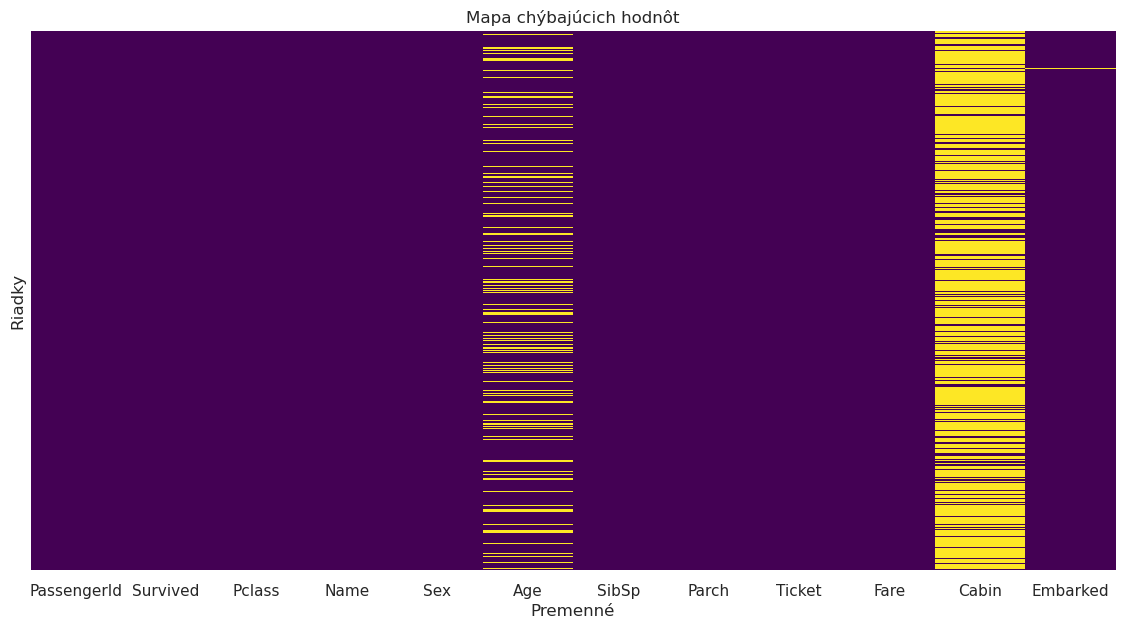

In [11]:
#vizualizácia missing values
plt.figure(figsize=(14, 7))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa chýbajúcich hodnôt")
plt.xlabel("Premenné")
plt.ylabel("Riadky")
plt.show()

### Identifikácia premenných:
Problém je v premenných Age, Cabin a aj Embarked, kde sú chýbajúce premenné. Najhoršie je na tom Cabin, keďže má až vyšše 77,10% chýbajúcich hodnôt.

### Stratégia riešenia:
- **Age:** môžme nahradiť chybajúce hodnoty mediánom
- **Cabin:** keďže má až 77,10% chybajúcich hodnôt, tak sa neoplatí imputovať
- **Embarked:** kľudne môžme imputovať pomocou módusu

V tomto prípade by chýbanie mohlo byť samo o sebe informatívne pokiaľ ide o Age a Embarked - môže teda ísť o to, že pasažieri ich nechceli uviesť. 

## 4. Univariačná EDA - jedna premenná

**Numerické premenné**

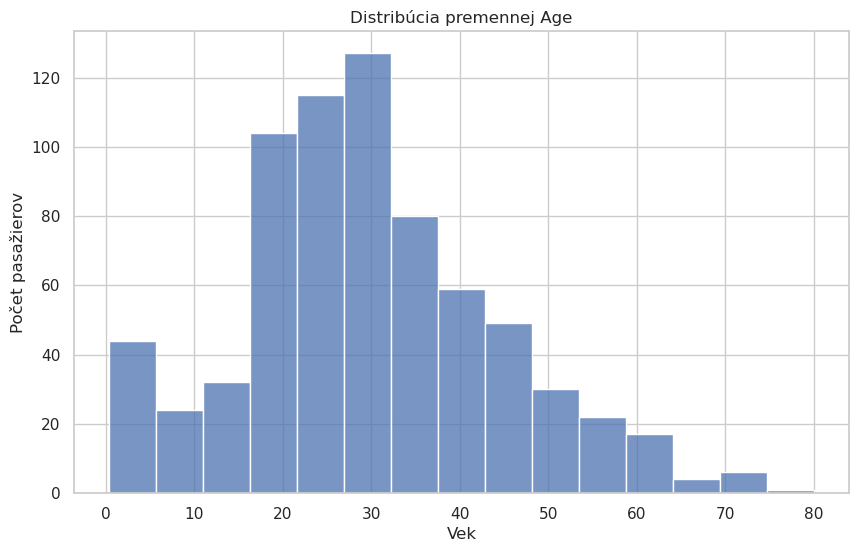

In [12]:
#vizualizácia Age pomocou histogramu
sns.histplot(df["Age"], bins = 15) #bins určuje počet intervalov, na koľko chceme dáta deliť
plt.title("Distribúcia premennej Age")
plt.xlabel("Vek")
plt.ylabel("Počet pasažierov")
plt.show()

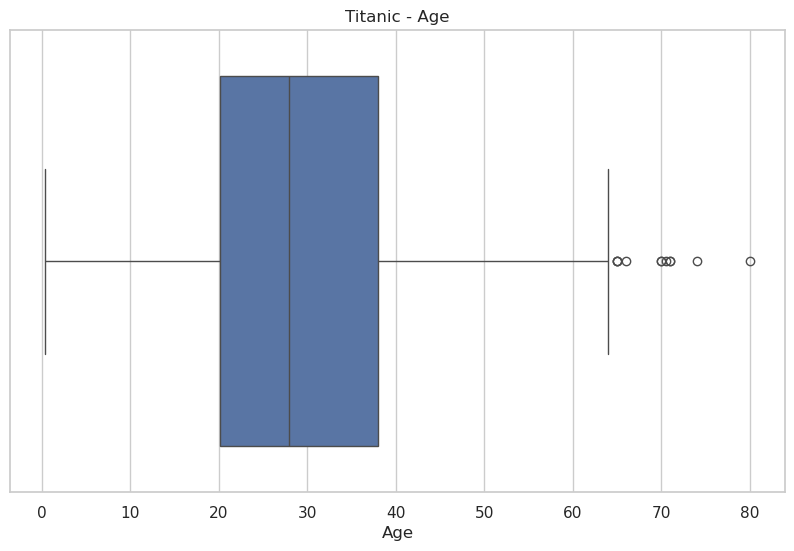

In [13]:
#vizualizácia Age pomocou boxplotu
sns.boxplot(x = df["Age"])
plt.title("Titanic - Age")
plt.show()

Najviac pasažierov malo okolo 30 rokov. Vidíme aj extrémne hodnoty nad viac ako 60 rokov do 80 rokov.

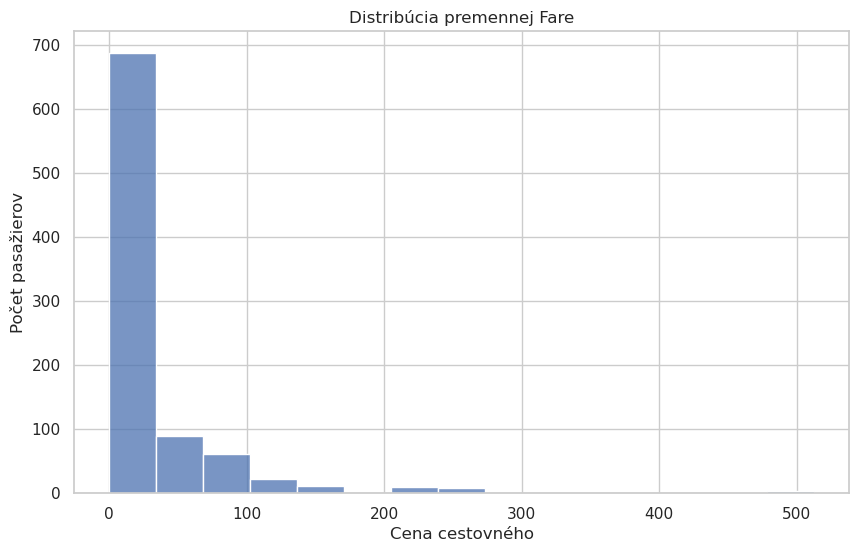

In [14]:
#vizualizácia Fare pomocou histogramu
sns.histplot(df["Fare"], bins = 15) 
plt.title("Distribúcia premennej Fare")
plt.xlabel("Cena cestovného")
plt.ylabel("Počet pasažierov")
plt.show()

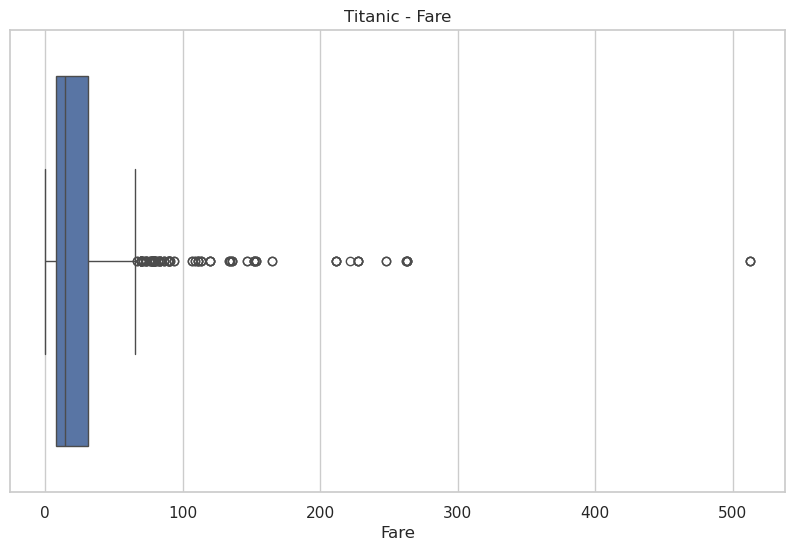

In [15]:
#vizualizácia Fare pomocou boxplotu
sns.boxplot(x = df["Fare"])
plt.title("Titanic - Fare")
plt.show()

Ide o velmi šikmé rozdelenie.

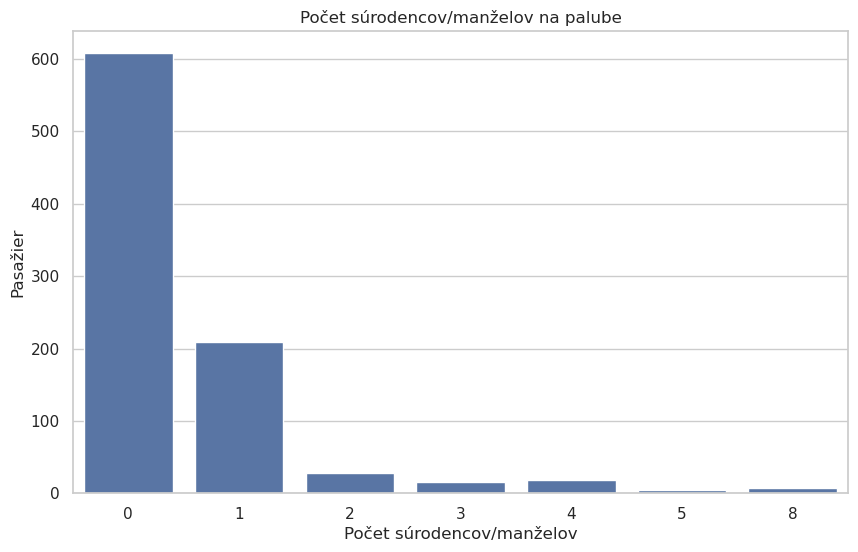

In [17]:
#počet SibSp
sns.countplot(x = "SibSp", data = df)
plt.title("Počet súrodencov/manželov na palube")
plt.xlabel("Počet súrodencov/manželov")
plt.ylabel("Pasažier")
plt.show()

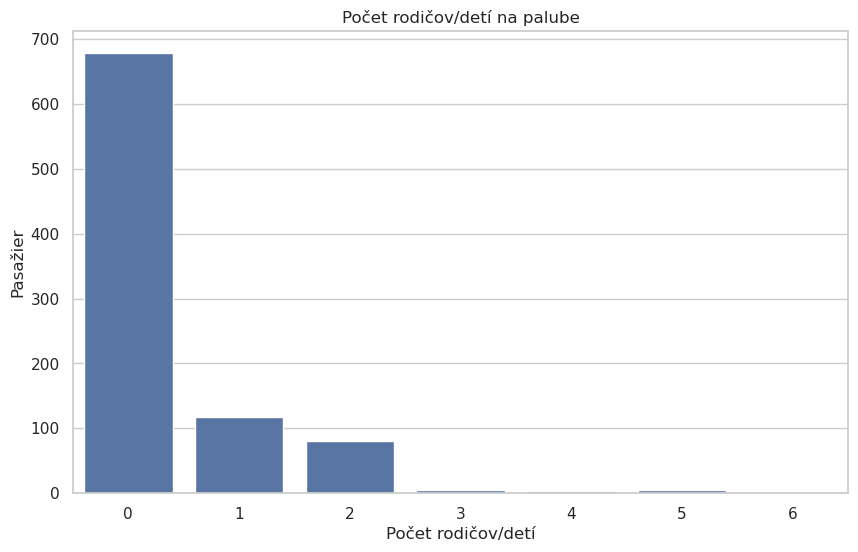

In [18]:
#počet Parch
sns.countplot(x = "Parch", data = df)
plt.title("Počet rodičov/detí na palube")
plt.xlabel("Počet rodičov/detí")
plt.ylabel("Pasažier")
plt.show()

Vačšina pasažierov nemala na palube súrodencov/manželov a ani rodičov/detí.

**Kategorické premenné** 

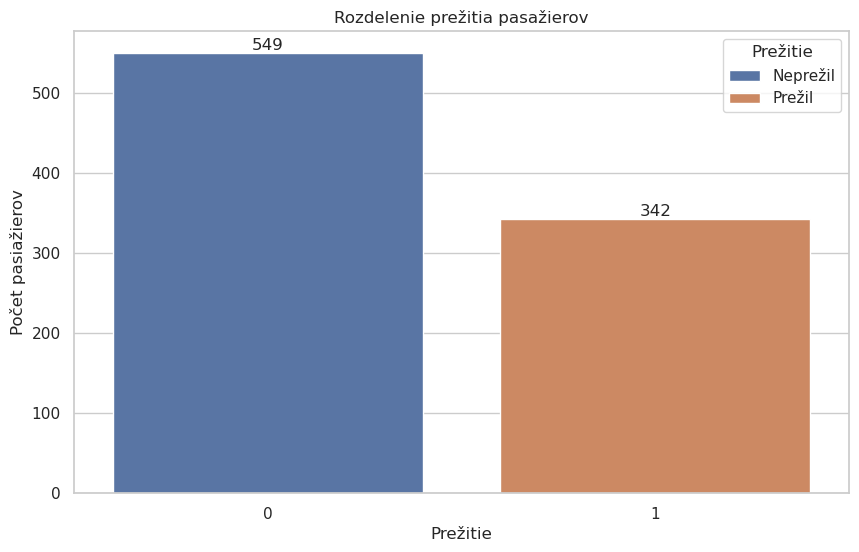

In [21]:
#rozdelenie premennej Survived
ax = sns.countplot(x = "Survived", data = df, hue = "Survived")
plt.title("Rozdelenie prežitia pasažierov")
plt.xlabel("Prežitie")
plt.ylabel("Počet pasiažierov")
plt.legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

#pridanie hodnôt nad stĺpce
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

Prežilo 549 pasažierov a neprežilo 342 pasažierov.

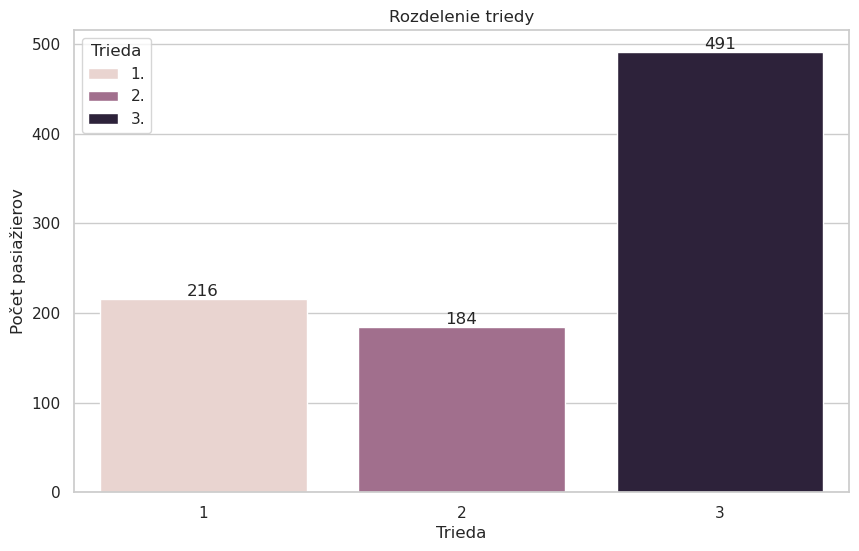

In [22]:
#rozdelenie premennej Pclass
ax = sns.countplot(x = "Pclass", data = df, hue = "Pclass")
plt.title("Rozdelenie triedy")
plt.xlabel("Trieda")
plt.ylabel("Počet pasiažierov")
plt.legend(title = "Trieda", labels = ["1.", "2.", "3."])

#pridanie hodnôt nad stĺpce
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

V datasete je najviac zastúpená **3. trieda**.

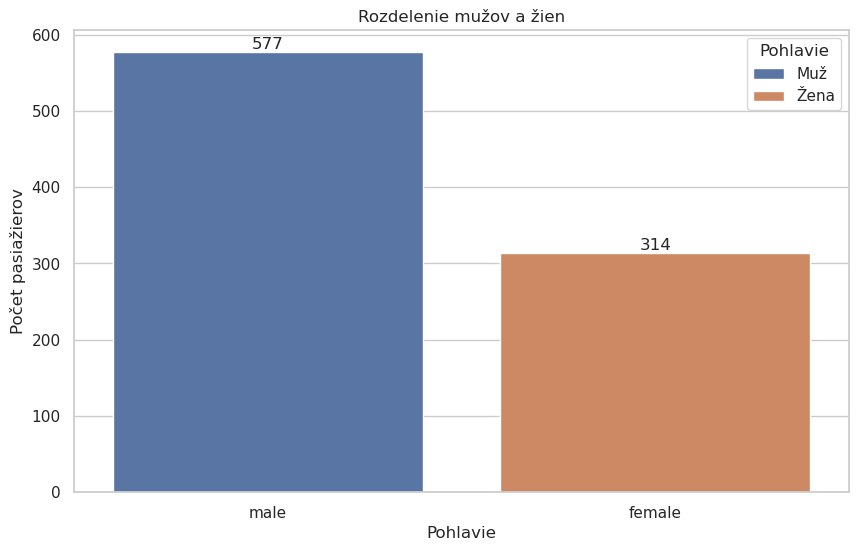

In [23]:
#rozdelenie premennej Sex
ax = sns.countplot(x = "Sex", data = df, hue = "Sex")
plt.title("Rozdelenie mužov a žien")
plt.xlabel("Pohlavie")
plt.ylabel("Počet pasiažierov")
plt.legend(title = "Pohlavie", labels = ["Muž", "Žena"])

#pridanie hodnôt nad stĺpce
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

Mužov bolo na palube skoro o polovicu viac ako žien.

- Fare, SibSp aj Parch sú silno pravostranné.
- Najviac vo Fare vidno potenciálne outliery - tých 500 dačo EUR.
- Treidy ani pohlavie nie sú v datasete zastúpené vyvážene.

## 5. Otliery a podozrivé hodnoty

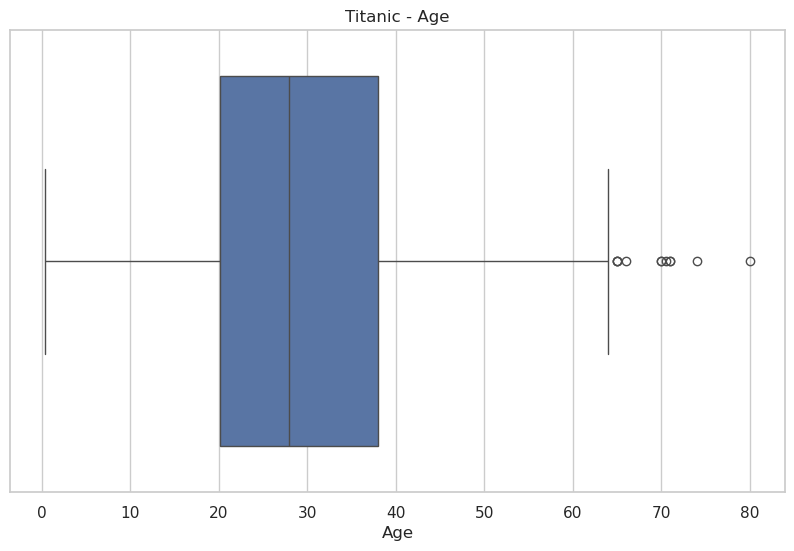

Počet outlierov v Age: 11


,PassengerId,Name,Pclass,Age
630,631,"Barkworth, Mr. Algernon Henry Wilson",1,80.0
851,852,"Svensson, Mr. Johan",3,74.0
96,97,"Goldschmidt, Mr. George B",1,71.0
493,494,"Artagaveytia, Mr. Ramon",1,71.0
116,117,"Connors, Mr. Patrick",3,70.5
672,673,"Mitchell, Mr. Henry Michael",2,70.0
745,746,"Crosby, Capt. Edward Gifford",1,70.0
33,34,"Wheadon, Mr. Edward H",2,66.0
54,55,"Ostby, Mr. Engelhart Cornelius",1,65.0
456,457,"Millet, Mr. Francis Davis",1,65.0


In [27]:
#Age outliery
sns.boxplot(x = df["Age"])
plt.title("Titanic - Age")
plt.show()

q1 = df["Age"].quantile(0.25)        
q3 = df["Age"].quantile(0.75)        
iqr = q3 - q1                                    
lower = q1 - 1.5 * iqr                           
upper = q3 + 1.5 * iqr                           

age_outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print("Počet outlierov v Age:", len(age_outliers))   
display(age_outliers[["PassengerId", "Name", "Pclass", "Age"]].sort_values("Age", ascending = False).head(10))

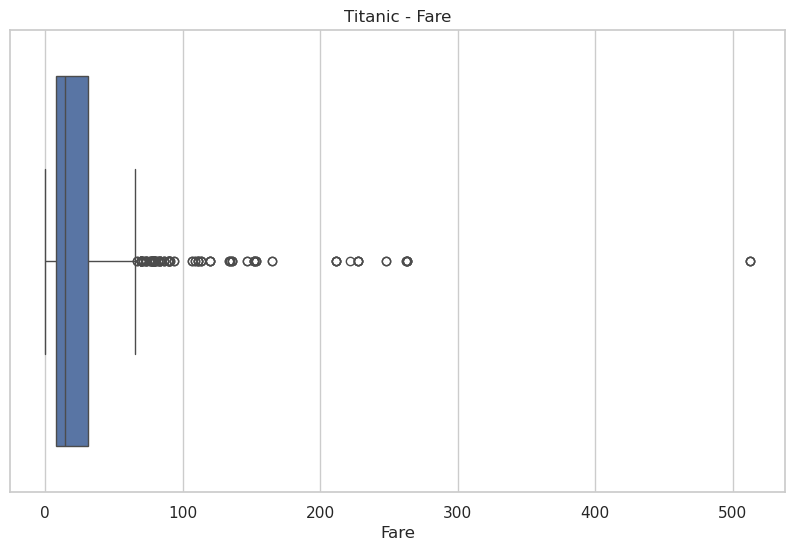

Počet outlierov vo Fare: 116


,PassengerId,Name,Pclass,Fare
737,738,"Lesurer, Mr. Gustave J",1,512.3292
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
258,259,"Ward, Miss. Anna",1,512.3292
27,28,"Fortune, Mr. Charles Alexander",1,263.0000
438,439,"Fortune, Mr. Mark",1,263.0000
88,89,"Fortune, Miss. Mabel Helen",1,263.0000
341,342,"Fortune, Miss. Alice Elizabeth",1,263.0000
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",1,262.3750
311,312,"Ryerson, Miss. Emily Borie",1,262.3750
118,119,"Baxter, Mr. Quigg Edmond",1,247.5208


In [28]:
#Fare outlery
sns.boxplot(x = df["Fare"])
plt.title("Titanic - Fare")
plt.show()

q1 = df["Fare"].quantile(0.25)        
q3 = df["Fare"].quantile(0.75)        
iqr = q3 - q1                                    
lower = q1 - 1.5 * iqr                           
upper = q3 + 1.5 * iqr                           

fare_outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]
print("Počet outlierov vo Fare:", len(fare_outliers))   
display(fare_outliers[["PassengerId", "Name", "Pclass", "Fare"]].sort_values("Fare", ascending = False).head(10))

In [30]:
#nulové hodnoty
(df[["Age", "Fare", "SibSp", "Parch"]] == 0).sum()

#extrémne neobvyklé hodnoty
# už identifikované v predchádzajúcej úlohe

Age        0
Fare      15
SibSp    608
Parch    678
dtype: int64

- Ponechala by som outliery v Age aj vo Fare. V Age je to bežné že by človek mal 80 rokov a cena cestovného lístka môže byť aj 500 EUR.
- Neodstránila by som žiadne.
- Transformovala by som vo Fare nulové hodnoty na free, keďže mi potom tých 15 nnúlových hodnôt môže mať nie celkom dobrý dopad na medián/priemer (čo keby som musela imputovať missing values).
- Vysoká cena cestovného môže byť realistická hodnota.
- Vek 0 sa môže brať ako ešte novorodenec nie starší ako 1 rok.
- Není vhodné odstraňovať outliery automaticky bez kontextu lebo nemáme dostatočné infomrácie o nich a môžu byť reálne.



## 6. Bivariačná EDA - vzťah k prežitiu

Kontingenčná tabuľka Pclass vs Survived:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


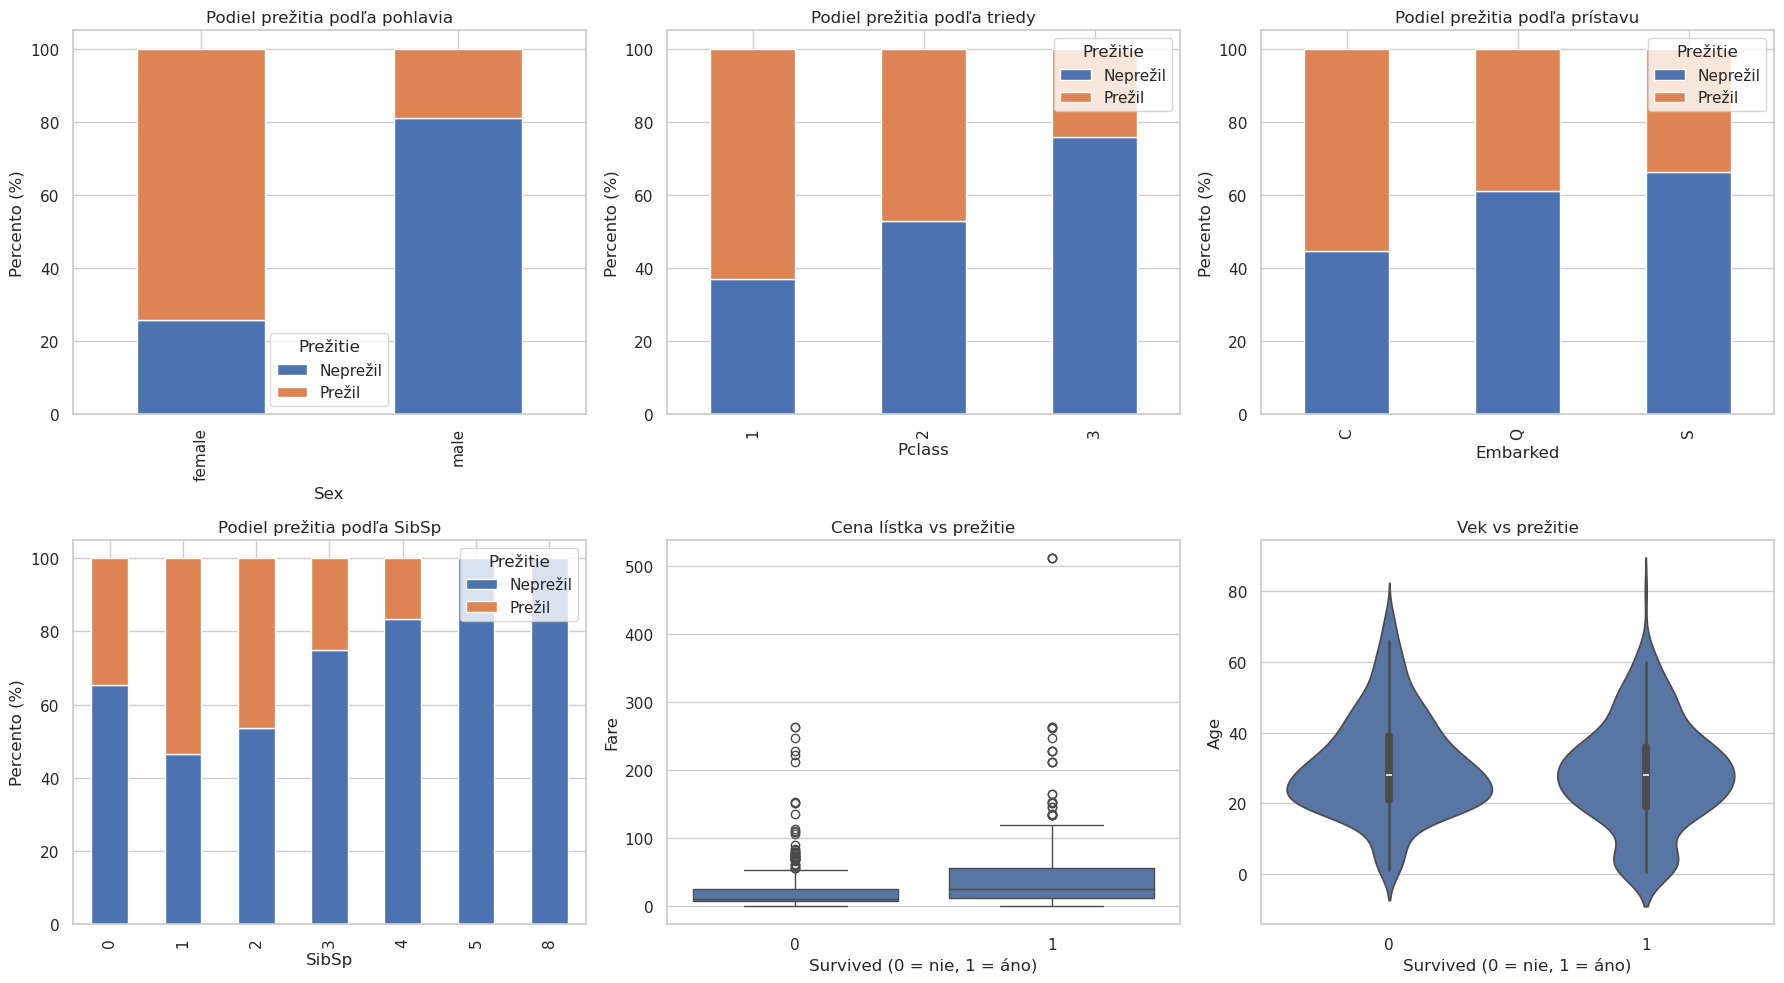

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#Survived vs Sex
counts = pd.crosstab(df["Sex"], df["Survived"], normalize = "index") * 100
counts.plot(kind = "bar", stacked = True, ax = axes[0, 0])

axes[0, 0].set_title("Podiel prežitia podľa pohlavia")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Percento (%)")
axes[0, 0].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])


#Survived vs Pclass
#graf
counts_pclass = pd.crosstab(df["Pclass"], df["Survived"], normalize = "index") * 100

counts_pclass.plot(kind = "bar", stacked = True, ax = axes[0, 1])

axes[0, 1].set_title("Podiel prežitia podľa triedy")
axes[0, 1].set_xlabel("Pclass")
axes[0, 1].set_ylabel("Percento (%)")
axes[0, 1].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

# kontingenčná tabuľka
print("Kontingenčná tabuľka Pclass vs Survived:")
print(pd.crosstab(df["Pclass"], df["Survived"]))

#Survived vs Embarked
counts_emb = pd.crosstab(df["Embarked"], df["Survived"], normalize = "index") * 100
counts_emb.plot(kind = "bar", stacked = True, ax = axes[0, 2])

axes[0, 2].set_title("Podiel prežitia podľa prístavu")
axes[0, 2].set_xlabel("Embarked")
axes[0, 2].set_ylabel("Percento (%)")
axes[0, 2].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])


#Survived vs SibSp 
counts_sib = pd.crosstab(df["SibSp"], df["Survived"], normalize = "index") * 100
counts_sib.plot(kind = "bar", stacked = True, ax = axes[1, 0])

axes[1, 0].set_title("Podiel prežitia podľa SibSp")
axes[1, 0].set_xlabel("SibSp")
axes[1, 0].set_ylabel("Percento (%)")
axes[1, 0].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])


# Fare vs Survived
sns.boxplot(data = df, x = "Survived", y = "Fare", ax = axes[1, 1])

axes[1, 1].set_title("Cena lístka vs prežitie")
axes[1, 1].set_xlabel("Survived (0 = nie, 1 = áno)")
axes[1, 1].set_ylabel("Fare")


#Survived vs Age
sns.violinplot(data = df, x = "Survived", y = "Age", ax = axes[1, 2])

axes[1, 2].set_title("Vek vs prežitie")
axes[1, 2].set_xlabel("Survived (0 = nie, 1 = áno)")
axes[1, 2].set_ylabel("Age")


plt.tight_layout()
plt.show()

**Anylýza otázok:**
- Medzi preživšími a neprižívšími ani nie sú až také veľké rozdiely vo veku.
- Žien prežilo viac ako mužov.
- Áno, miera prežitia sa líši podľa cestovnej triedy - najviac prežilo v 1. triede.
- Áno, dospelý človek by mal mať väčšiu šancu na prežitie ako senior alebo dieta.
- Cena cestovného (Fare) nevyzerá byť premenná, ktorá by veľmi súvisela s prežitím.


- Najsilnešie s prežitím súvisia premenné Sex, Pclass, Age a SibSp.
- Zrejmé vzťahy sú Survived s Sex, Pclass, SibSp. Nejednoznačné sú Survived s Fare a aj tak s Age.
- Ziatiaľ treba byť stále všade opatrný. 

## 7. Multivačiačná EDA

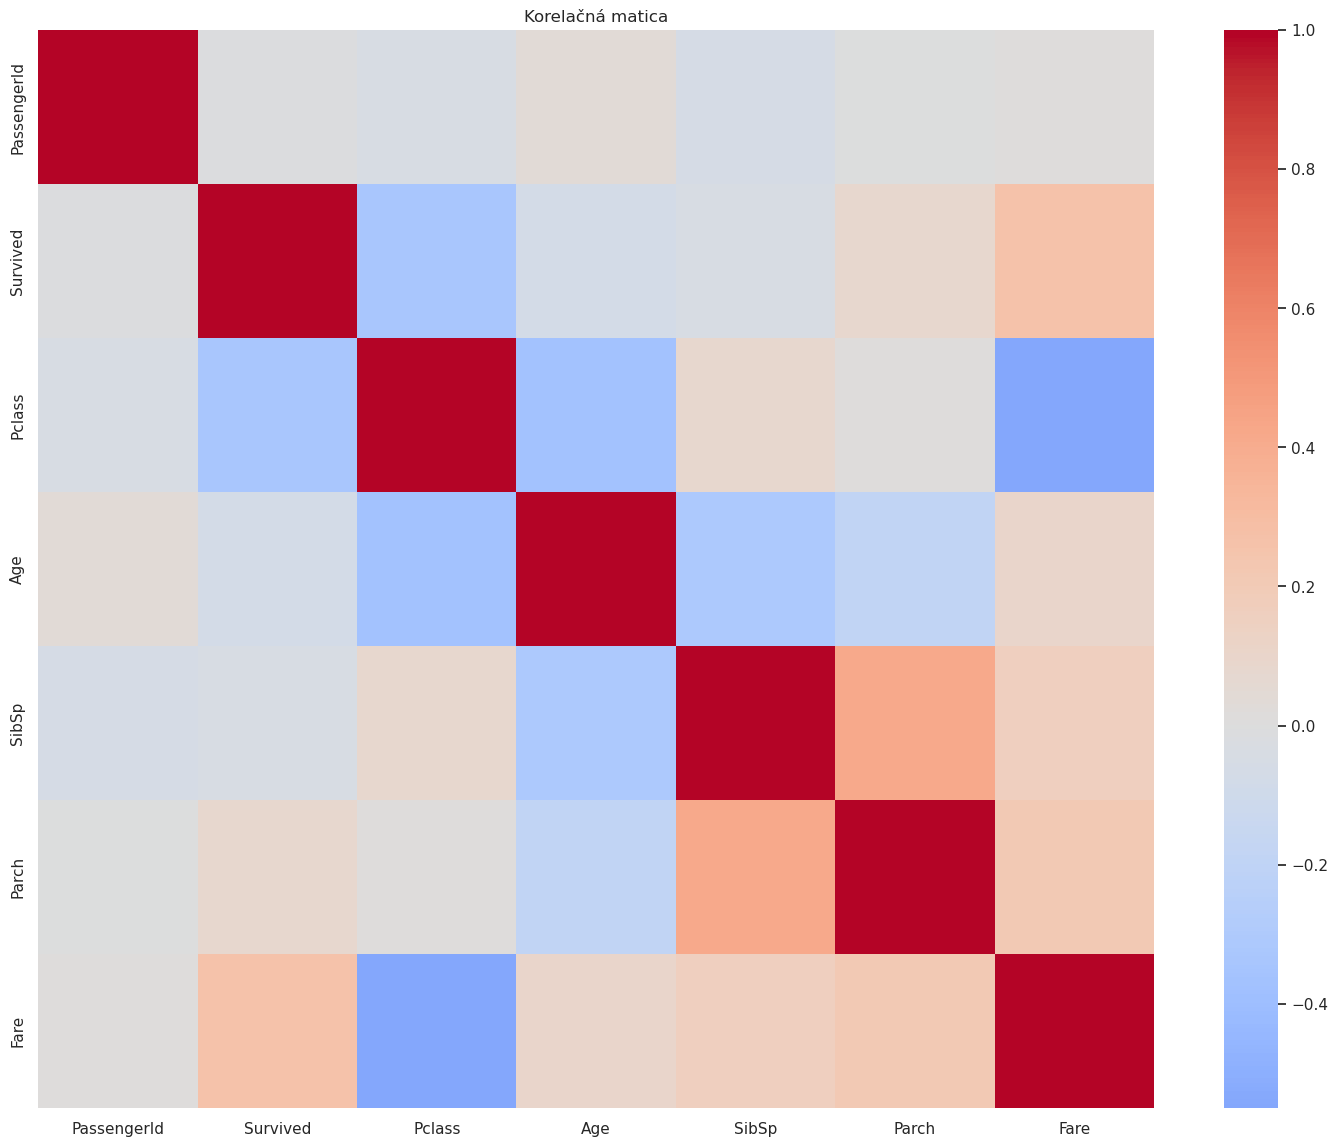

In [48]:
#korelačná matica pre numerické premenné
encoded = df.copy()
corr = encoded.corr(numeric_only = True)

#heatmapa
plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap = "coolwarm", center=0)
plt.title("Korelačná matica")
plt.show()


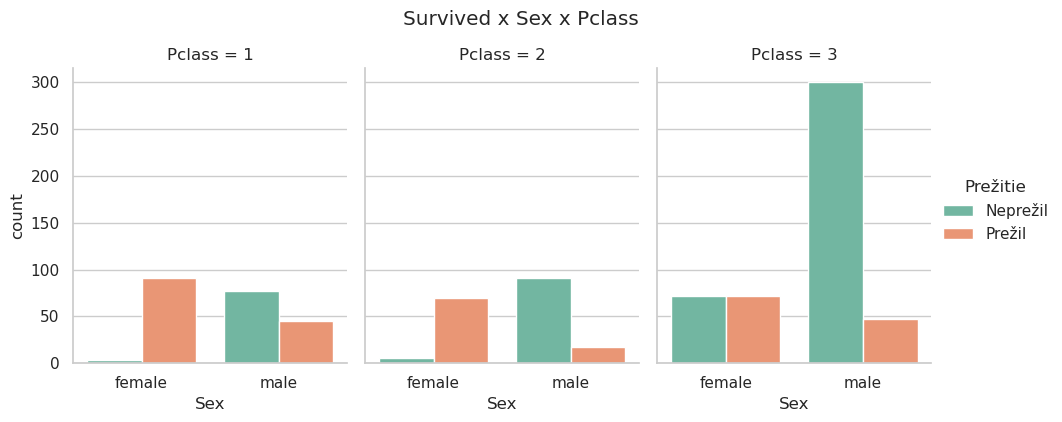

In [55]:
#preskúmanie vzťahov
#Survived x Sex x Pclass
sns.FacetGrid(df, col = "Pclass", height = 4, aspect = 0.8).map_dataframe(
    sns.countplot,
    x = "Sex",
    hue = "Survived",
    palette="Set2"
).add_legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

plt.suptitle("Survived x Sex x Pclass", y = 1.05)
plt.show()





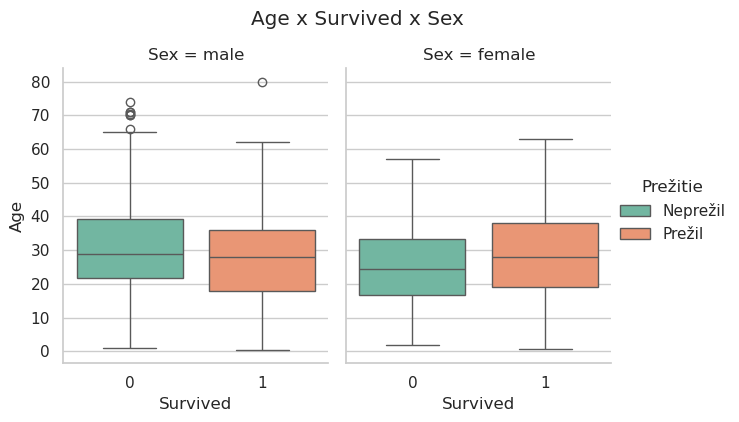

In [57]:
#Survived x Age x Sex
sns.FacetGrid(df, col = "Sex", height = 4, aspect = 0.8).map_dataframe(
    sns.boxplot,
    x = "Survived",
    y = "Age",
    hue = "Survived",
    palette = "Set2"
).add_legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

plt.suptitle("Age x Survived x Sex", y = 1.05)
plt.show()

- Vťah sa mení medzi pohlavím a prežitím v rôznych triedach.
- Áno, vidno interakcie, ktoré by pri jednoduchej bivariačnej analýze zostali skryté.

## 8. Jednoduchý feature engineering pre EDA

In [63]:
#vytvorenie premennej FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

#vytvorenie premennej IsAlone 
df["IsAlone"] = (df["SibSp"] + df["Parch"] == 0).astype(int)

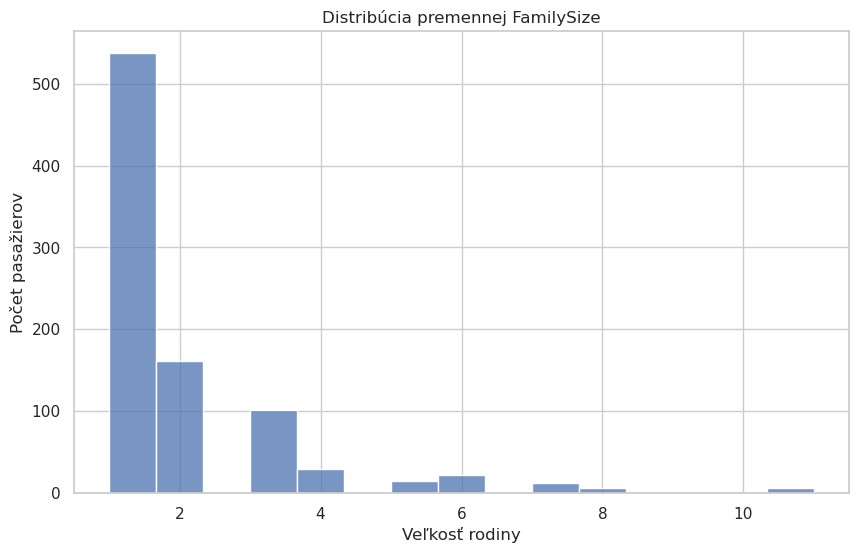

In [61]:
#distribúcia FamilySize
sns.histplot(df["FamilySize"], bins = 15) 
plt.title("Distribúcia premennej FamilySize")
plt.xlabel("Veľkosť rodiny")
plt.ylabel("Počet pasažierov")
plt.show()

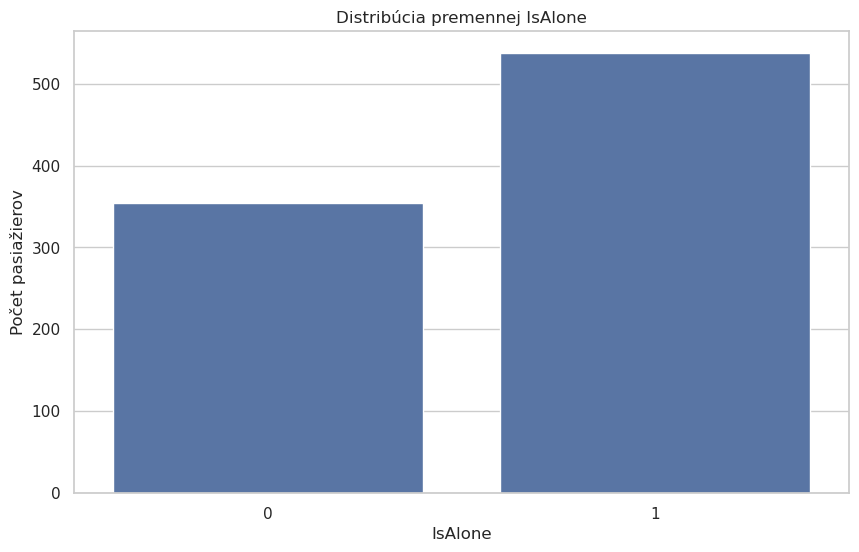

In [71]:
#distribúcia IsAlone
sns.countplot(x = "IsAlone", data = df)
plt.title("Distribúcia premennej IsAlone")
plt.xlabel("IsAlone")
plt.ylabel("Počet pasiažierov")
plt.show()


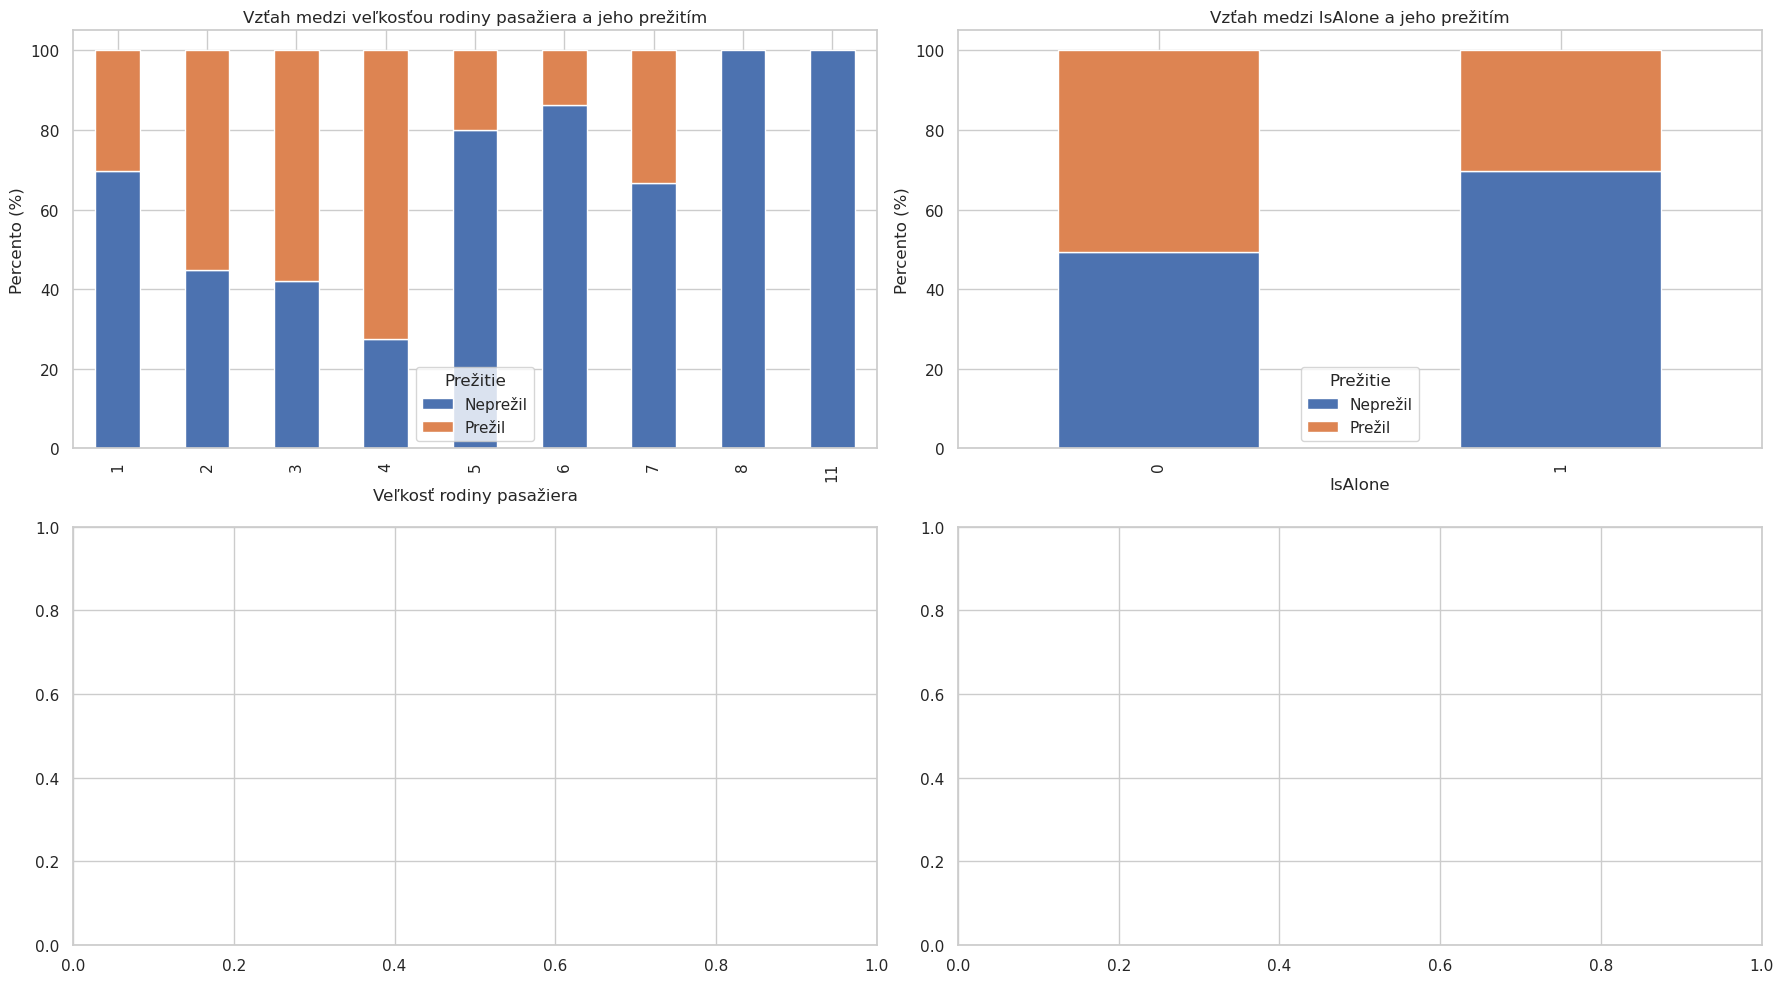

In [78]:
#zistenie, či súvisia s prežitím
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

#Survived x FamilySize
counts = pd.crosstab(df["FamilySize"], df["Survived"], normalize = "index") * 100
counts.plot(kind = "bar", stacked = True, ax = axes[0, 0])

axes[0, 0].set_title("Vzťah medzi veľkosťou rodiny pasažiera a jeho prežitím")
axes[0, 0].set_xlabel("Veľkosť rodiny pasažiera")
axes[0, 0].set_ylabel("Percento (%)")
axes[0, 0].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

#Survived x IsAlone
counts = pd.crosstab(df["IsAlone"], df["Survived"], normalize = "index") * 100
counts.plot(kind = "bar", stacked = True, ax = axes[0, 1])

axes[0, 1].set_title("Vzťah medzi IsAlone a jeho prežitím")
axes[0, 1].set_xlabel("IsAlone")
axes[0, 1].set_ylabel("Percento (%)")
axes[0, 1].legend(title = "Prežitie", labels = ["Neprežil", "Prežil"])

plt.tight_layout()
plt.show()

Súvisia s prežitím, keďže ako vidíme podľa grafov, pasažieri, ktorí nemali žiadných členov rodiny, mali vačšiu šancu prežiť. Tieto premenné by mohli byť užitočné pri modelovaní, keby sme chceli zistiť, či veľkosť rodiny má dopad na prežitie.

## 9. Návrh čistenia a prípravy dát

### Kroky:
- **Ponechať premenné:** Survived, Sex, Age, Pclass, SibSp, Parch (užitočné na zistenie šance prežitia)
- **Odstrániť premenné:** Cabin (veľa chýbajúcich hodnôt)
- **Ošetretnie missing values:** Age - medián (numerická), Embarked - módus(kategória)
- **Zákodovať kategórie:** v každej ponechanej kategorickej premennej dať každej unikátnej hodnote číslo (Napr. Sex - 0 = Male, 1 = Female)
- **Zmysel škálovať:** iba pri premenných Age a Fare (veľké rozdiely)
- **Ponechať nové premenné:** FamilySize, IsAlone